# Basic ML Life Cycle Overview 
### From data to deployment

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
#Load the dataset
df = pd.read_csv("placement.csv")
print(df.head())

   Unnamed: 0  cgpa     iq  placement
0           0   6.8  123.0          1
1           1   5.9  106.0          0
2           2   5.3  121.0          0
3           3   7.4  132.0          1
4           4   5.8  142.0          0


## Steps 

0. Preprocess + EDA + feature selection
1. Extract input and output cols
2. Scale values
3. Train, test split
4. Train the model
5. Evauate the model/ model selection
6. Deploy the model

### Example of preprocessing

In [ ]:
# Unnamed column useless -> remove 
df = df.iloc[:, 1:]
print(df.head())

   cgpa     iq  placement
0   6.8  123.0          1
1   5.9  106.0          0
2   5.3  121.0          0
3   7.4  132.0          1
4   5.8  142.0          0


In [ ]:
print(df.info()) #returns meta data about the columns
#useful for looking for missign data/ null values/ etc

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None


### Example of EDA 

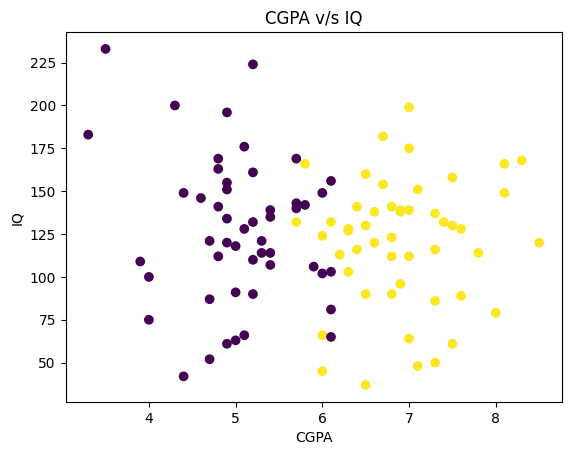

In [16]:
#Plotting cgpa vs iq (scatter plot)
plt.scatter(df["cgpa"], df["iq"], c=df["placement"]) #plt.scatter(x-axis, y-axis, color = placement) #color based on placement col
plt.title("CGPA v/s IQ")
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.show()

We can analyse the data and can see that it can be lineraly separated so we may use logistic regression to separate the data

### Separating the input and output cols

In [17]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [18]:
print(X.shape)
print(X.head())

(100, 2)
   cgpa     iq
0   6.8  123.0
1   5.9  106.0
2   5.3  121.0
3   7.4  132.0
4   5.8  142.0


In [21]:
print(y.shape)
print(y.head())

(100,)
0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64


### Train-test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1) #test dataset = 10% of the whole dataset 
#you can print all these and see 

### Scaling the data

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # scaler object
X_train = scaler.fit_transform(X_train) #transforms the dataframe into array
print(X_train)

[[-7.00991473e-01  2.42567441e+00]
 [ 1.17029932e+00  3.13225224e-01]
 [ 1.79406292e+00 -1.09507423e+00]
 [-8.79209645e-01 -8.03701931e-01]
 [-5.22773302e-01 -2.45238354e-01]
 [-1.66336960e-01  4.34630350e-01]
 [-2.55446045e-01  1.09021803e+00]
 [-9.68318730e-01 -1.53213268e+00]
 [ 1.18812114e-02 -5.36610655e-01]
 [-1.23564599e+00  5.31754450e-01]
 [ 9.02972067e-01  1.23590418e+00]
 [ 1.18812114e-02 -2.42810251e-03]
 [ 1.00990297e-01 -1.04651218e+00]
 [ 9.92081153e-01 -1.84778601e+00]
 [ 1.25940841e+00  1.91820098e-01]
 [-7.90100559e-01  1.26018520e+00]
 [ 7.24753896e-01 -2.93800404e-01]
 [-1.14653690e+00 -9.00826032e-01]
 [-2.39406410e+00  1.43015238e+00]
 [-5.22773302e-01 -4.15205529e-01]
 [ 1.17029932e+00 -1.79922396e+00]
 [-1.14653690e+00 -7.52711779e-02]
 [-1.05742782e+00  9.44531877e-01]
 [-8.79209645e-01 -1.48357063e+00]
 [-9.68318730e-01  6.53159576e-01]
 [-1.41386416e+00 -1.99347216e+00]
 [ 1.00990297e-01 -1.43500858e+00]
 [ 1.00990297e-01  1.91820098e-01]
 [ 8.13862982e-01 -6

In [39]:
X_test = scaler.transform(X_test) #pattern understood by the class in the prev operation of scaling X_train so now just tranform this dataframe according to that same pattern or fit
print(X_test)

[[  6.6 120. ]
 [  5.4 139. ]
 [  3.9 109. ]
 [  7.8 114. ]
 [  6.3 103. ]
 [  5.1  66. ]
 [  5.  118. ]
 [  8.1 149. ]
 [  5.2 132. ]
 [  6.9 139. ]]


## Training the model

In [43]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression() #LP Object

In [44]:
#training the model
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Evaluating the model

In [46]:
y_pred = clf.predict(X_test)

### Comparing predicted and actual output values

In [48]:
from sklearn.metrics import accuracy_score

In [49]:
accuracy_score(y_test, y_pred) #compare actual and predicted output values and returns the accuracy score

0.5

## Plotting the decision boundary

mlxtend - Machine Learning Extensions - library that provides tools complementing the other machine learning libraries - np, pd and sklearn
key functionalities : ensemble methods, feature selection, visualization, pattern mining and model evaluation & analysis

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

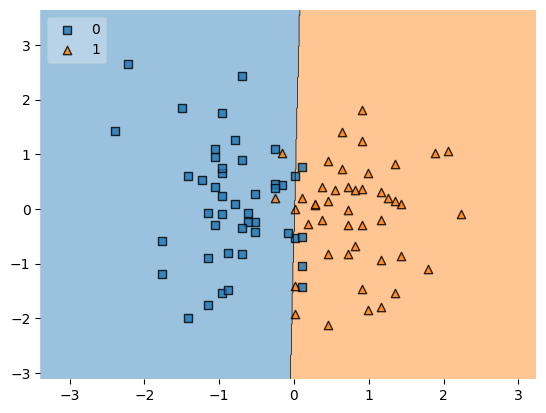

In [52]:
#plot the decision regions
plot_decision_regions(X_train, y_train.values, clf=clf , legend=2) 

## Exporting the model

pickle library - converts objects into files(json) which can then be exported and used in other environments (already installed with python)

In [53]:
import pickle

In [54]:
pickle.dump(clf, open('model.pkl', 'wb')) 
# dump the clf object (our classifier model into a file, and when it opens -> name = model.pkl and open it in the WriteBinary mode)